# Problem Title - Scratch Mode
Issue: #<issue-number>

## 1. Setup and Imports
Use only NumPy and pandas for scratch work; do not use ML libraries unless the issue explicitly allows them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load and Inspect Data
Load dataset.csv and validate shape, columns, and missing values before training.

In [9]:
url = "https://raw.githubusercontent.com/iiitl/Linear-Regression/main/dataset.csv"
df = pd.read_csv(url)

print("\nColumns:", df.columns.tolist())

df.head()


Columns: ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Concrete compressive strength']


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Cement                         1030 non-null   float64
 1   Blast Furnace Slag             1030 non-null   float64
 2   Fly Ash                        1030 non-null   float64
 3   Water                          1030 non-null   float64
 4   Superplasticizer               1030 non-null   float64
 5   Coarse Aggregate               1030 non-null   float64
 6   Fine Aggregate                 1030 non-null   float64
 7   Age                            1030 non-null   int64  
 8   Concrete compressive strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [4]:
df.shape

(1030, 9)

In [6]:
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Concrete compressive strength,0


In [10]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [11]:
df.columns

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age',
       'Concrete compressive strength'],
      dtype='object')

## 3. Preprocessing
Prepare features and target explicitly, including any normalization or encoding steps.

In [12]:
# Separate features and target
# Correct target column
target_col = 'Concrete compressive strength'

X = df.drop(columns=[target_col]).values
y = df[target_col].values.reshape(-1, 1)

# Train-test split (manual to stay "scratch-friendly")
np.random.seed(42)
indices = np.random.permutation(len(X))

split = int(0.8 * len(X))
train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Feature scaling (CRUCIAL for gradient descent)
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-8  # avoid division by zero

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# Add bias term
def add_bias(X):
    return np.c_[np.ones((X.shape[0], 1)), X]

X_train = add_bias(X_train)
X_test = add_bias(X_test)

## 4. Algorithm Implementation
Implement core model logic from scratch and keep helper functions readable and testable.

In [13]:
def compute_loss(X, y, theta):
    m = len(y)
    predictions = X @ theta
    return (1 / (2 * m)) * np.sum((predictions - y) ** 2)


def gradient_descent(X, y, lr=0.01, epochs=1000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    losses = []

    for i in range(epochs):
        predictions = X @ theta
        error = predictions - y

        gradient = (1 / m) * (X.T @ error)
        theta -= lr * gradient

        loss = compute_loss(X, y, theta)
        losses.append(loss)

        # Optional: print occasionally
        if i % 200 == 0:
            print(f"Epoch {i}, Loss: {loss:.4f}")

    return theta, losses

## 5. Training
Train your scratch implementation and track learning behavior across iterations.

In [14]:
theta, losses = gradient_descent(X_train, y_train, lr=0.01, epochs=1000)

Epoch 0, Loss: 773.5142
Epoch 200, Loss: 71.4340
Epoch 400, Loss: 57.5265
Epoch 600, Loss: 56.3396
Epoch 800, Loss: 55.7755


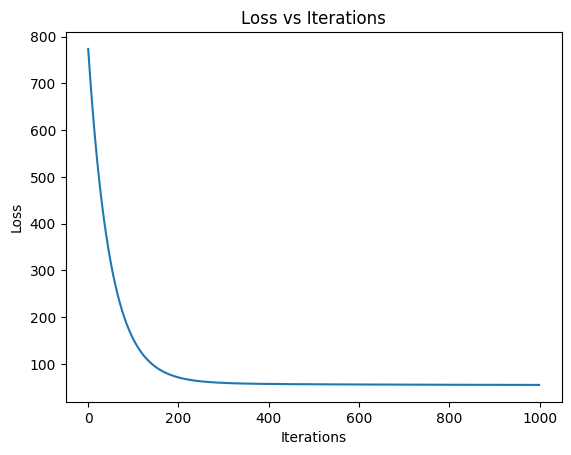

In [15]:
plt.figure()
plt.plot(losses)
plt.title("Loss vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

## 6. Evaluation
Report the correct metric clearly and compare achieved value with target threshold.

In [16]:
# Predictions
y_pred = X_test @ theta

# Metrics (from scratch)
def MAE(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def RMSE(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def R2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

mae = MAE(y_test, y_pred)
rmse = RMSE(y_test, y_pred)
r2 = R2(y_test, y_pred)

print("\nEvaluation Metrics:")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)


Evaluation Metrics:
MAE : 8.168177532315458
RMSE: 10.205953960851753
R2  : 0.5584825873903905


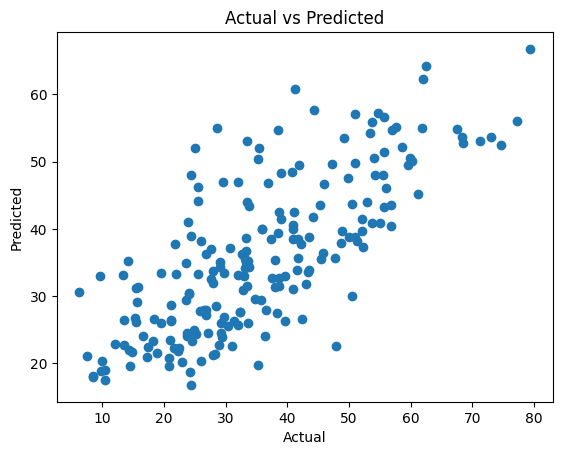

In [17]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

## 7. Summary
Answer only these scratch-training questions:
1. Which core steps did you implement from scratch (math + code)?
2. How did your training behavior change over iterations (loss/metric trend), and what explains it?
3. What have you learned from implementing and evaluating this model from scratch in this notebook?

### Summary

**1. Core steps implemented from scratch**
- Data preprocessing (train-test split, normalization, bias term)
- Linear regression hypothesis: \( y = X\theta \)
- Loss function: Mean Squared Error (MSE)
- Gradient computation and parameter updates using full batch gradient descent
- Prediction and evaluation metrics (MAE, RMSE, R²)

**2. Training behavior over iterations**
- Loss decreased steadily and converged over iterations
- Initial sharp drop due to large gradients, then gradual stabilization near minimum
- Proper feature scaling ensured smooth and faster convergence

**3. Key learnings**
- Understanding of underlying math behind linear regression and gradient descent
- Importance of feature scaling for stable training
- Insight into how learning rate and iterations affect convergence and performance